# Part 2 – Exploratory analysis (delay threshold >= 1 minute)

This notebook performs an exploratory data analysis (EDA) for bus stop-level delays using a 1-minute threshold:

- `is_delayed = 1` if `delay_minutes >= 1`
- `is_delayed = 0` otherwise

The goals are:
- to understand how delays are distributed in time and across the network,
- to quantify the effect of weather,
- and to prepare a clean, modeling-ready dataset for Part 3.

## 1. Load cleaned data and define the delay label

We load the canonical CSV from Part 1 and create a binary target flag indicating whether each stop event is delayed beyond the chosen threshold. We also derive simple time-based features (hour, weekday, weekend flag, and time bands).

In [1]:
# 02_eda_delay.ipynb
# Part 2 – EDA for bus delays, DELAY_THRESHOLD = 1 minutes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: if you like seaborn for nicer plots
import seaborn as sns
sns.set(style="whitegrid")

# Adjust this path to the CSV exported by 01_data_understanding
DATA_PATH = "../data/bus_delays_sample.csv" 

DELAY_THRESHOLD = 1  # minutes

# Load data
df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (7356700, 10)


,stop_id,trip_id,planned_time,real_time,delay_minutes,collected_at,operator,transport_type,route_id,route_short_name
0,201103001,1|4421|1|82|25072025,2025-07-25 20:12:00,2025-07-25 20:13:00,1.0,2025-07-25 20:13:32,Régime Général des Transports Routiers,Bus,3209,413
1,201103001,1|7769|0|82|25072025,2025-07-25 20:18:00,2025-07-25 20:18:00,0.0,2025-07-25 20:13:32,Régime Général des Transports Routiers,Bus,3208,412
2,201103001,1|4404|4|82|25072025,2025-07-25 20:26:00,2025-07-25 20:26:00,0.0,2025-07-25 20:13:32,Régime Général des Transports Routiers,Bus,3208,412
3,201103001,1|7420|0|82|25072025,2025-07-25 20:27:00,2025-07-25 20:27:00,0.0,2025-07-25 20:13:32,Régime Général des Transports Routiers,Bus,3208,412
4,201103001,1|4443|10|82|25072025,2025-07-25 20:33:00,2025-07-25 20:33:00,0.0,2025-07-25 20:13:32,Régime Général des Transports Routiers,Bus,3210,501


In [2]:
# Convert datetime columns
datetime_cols = ["planned_time", "real_time", "collected_at"]

for col in datetime_cols:
    df_raw[col] = pd.to_datetime(df_raw[col])

print(df_raw.dtypes)

# Quick info + missing values
print("\nDataFrame info:")
df_raw.info()

print("\nMissing values per column:")
print(df_raw.isna().sum())

stop_id                      int64
trip_id                     object
planned_time        datetime64[ns]
real_time           datetime64[ns]
delay_minutes              float64
collected_at        datetime64[ns]
operator                    object
transport_type              object
route_id                     int64
route_short_name            object
dtype: object

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7356700 entries, 0 to 7356699
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   stop_id           int64         
 1   trip_id           object        
 2   planned_time      datetime64[ns]
 3   real_time         datetime64[ns]
 4   delay_minutes     float64       
 5   collected_at      datetime64[ns]
 6   operator          object        
 7   transport_type    object        
 8   route_id          int64         
 9   route_short_name  object        
dtypes: datetime64[ns](3), float64(1), int64(2), o

## 2. Time-based features and 1-minute delay label

In this section we:

- create time-based features from `planned_time` (hour of day, weekday, weekday name),
- mark weekends with a boolean flag,
- group hours into coarse time bands (night, morning peak, midday, evening peak, late evening),
- and define the binary target `is_delayed` based on a 1-minute delay threshold.

These features will be reused throughout the EDA and later in the modeling.

In [3]:
# Work copy of the dataset
df = df_raw.copy()

# ----- Time features derived from planned_time -----

# Hour of day (0–23)
df["planned_hour"] = df["planned_time"].dt.hour

# Day of week (0 = Monday, 6 = Sunday)
df["planned_weekday"] = df["planned_time"].dt.dayofweek

# Weekend flag
df["is_weekend"] = df["planned_weekday"].isin([5, 6])

# Time bands to simplify interpretation
def assign_time_band(hour):
    if 6 <= hour <= 9:
        return "morning_peak"
    elif 10 <= hour <= 15:
        return "midday"
    elif 16 <= hour <= 19:
        return "evening_peak"
    elif 20 <= hour <= 23:
        return "late_evening"
    else:
        return "night"

df["time_band"] = df["planned_hour"].apply(assign_time_band)

# Define binary target based on the chosen delay threshold
df["is_delayed"] = (df["delay_minutes"] >= DELAY_THRESHOLD).astype(int)

# Check class balance
print(f"Share of trips delayed >= {DELAY_THRESHOLD} minute:")
print(df["is_delayed"].value_counts(normalize=True).rename("proportion"))

Share of trips delayed >= 1 minute:
is_delayed
0    0.640209
1    0.359791
Name: proportion, dtype: float64


## 3. Handling missing operator values

A small fraction of rows have a missing `operator`. Instead of dropping these rows, we keep them and replace missing values with the label `"Unknown"`.

This preserves all observations while still allowing us to analyse operator-level patterns.

In [4]:
# Handle missing operator values
missing_before = df["operator"].isna().sum()
print("Missing 'operator' before:", missing_before)

# Keep all rows, but mark missing operator as 'Unknown'
df["operator"] = df["operator"].fillna("Unknown")

missing_after = df["operator"].isna().sum()
print("Missing 'operator' after:", missing_after)

# Quick check of top operators (including Unknown)
df["operator"].value_counts(dropna=False).head()

Missing 'operator' before: 6059
Missing 'operator' after: 0


operator
Régime Général des Transports Routiers                 3608687
Ville de Luxembourg - Service Autobus                  2701389
TICE                                                   1040174
Unknown                                                   6059
Société Nationale des Chemins de Fer Luxembourgeois        391
Name: count, dtype: int64

## 4. Delay distribution and class imbalance

We first look at the numeric distribution of `delay_minutes`:

- to understand how frequent early departures and extreme delays are,
- and to quantify how many events exceed the 1-minute threshold.

This also reveals the level of class imbalance in `is_delayed`, which is important for later modeling.

In [5]:
# Numeric distribution of delay_minutes
delay_desc = df["delay_minutes"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
print(delay_desc)

# Check min and max to inspect early departures and extreme delays
print("\nMin delay:", df["delay_minutes"].min())
print("Max delay:", df["delay_minutes"].max())

count    7.356700e+06
mean     1.021089e+00
std      2.755582e+00
min      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
90%      3.000000e+00
95%      5.000000e+00
99%      9.000000e+00
max      1.423000e+03
Name: delay_minutes, dtype: float64

Min delay: 0.0
Max delay: 1423.0


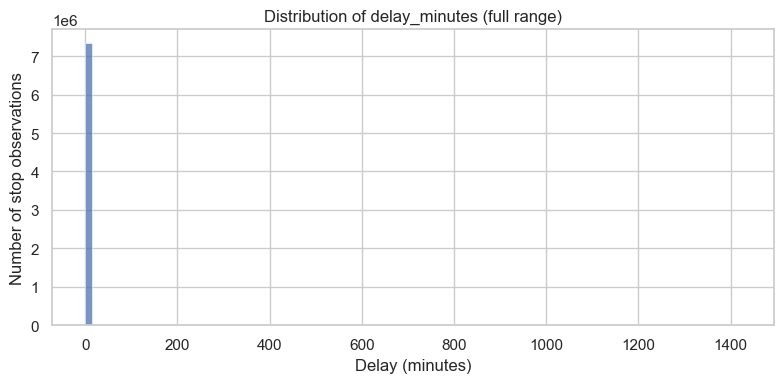

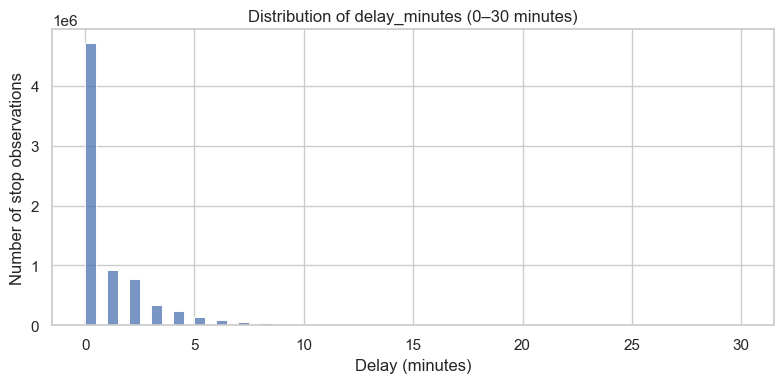

Share of trips delayed >= 1 minutes: 35.979%


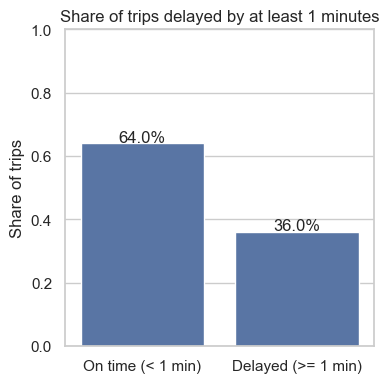

In [6]:
# ---------- 1) Full distribution of delay_minutes ----------

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["delay_minutes"], bins=100, kde=False, ax=ax)
ax.set_title("Distribution of delay_minutes (full range)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Number of stop observations")
plt.tight_layout()
plt.show()

# ---------- 2) Zoom on typical range (0–30 minutes) ----------
# Note: we do NOT drop any rows, just zoom the x-axis via filtering for the plot

df_delay_0_30 = df[df["delay_minutes"] <= 30]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_delay_0_30["delay_minutes"], bins=60, kde=False, ax=ax)
ax.set_title("Distribution of delay_minutes (0–30 minutes)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Number of stop observations")
plt.tight_layout()
plt.show()

# ---------- 3) Share of delayed vs non-delayed (>= 1 min) ----------

delay_rate = df["is_delayed"].mean()
print(f"Share of trips delayed >= {DELAY_THRESHOLD} minutes: {delay_rate:.3%}")

fig, ax = plt.subplots(figsize=(4, 4))

categories = ["On time (< 1 min)", "Delayed (>= 1 min)"]
values = [1 - delay_rate, delay_rate]

sns.barplot(x=categories, y=values, ax=ax)
ax.set_ylabel("Share of trips")
ax.set_title(f"Share of trips delayed by at least {DELAY_THRESHOLD} minutes")

# Annotate percentages on top of bars
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")

ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Time-of-day patterns

We now study how the risk of being delayed ≥ 1 minutes changes over time:

- by hour of day,
- by day of week,
- and by coarse time bands (morning peak, midday, evening peak, etc.).

This helps identify rush-hour effects and differences between weekdays and weekends.

   planned_hour  avg_delay  delayed_rate  n_obs
0             3   0.546667      0.293333     75
1             4   0.386468      0.210627   2616
2             5   0.574816      0.307786  23825
3             6   0.668339      0.292073  71941
4             7   0.743720      0.286557  98525


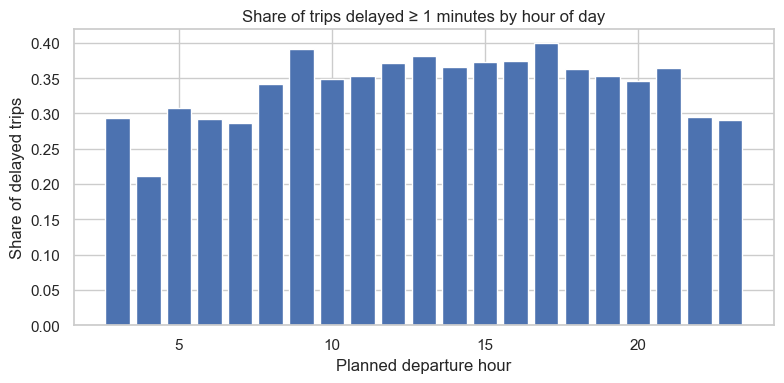

In [7]:
# EDA: delay patterns by hour of day (DELAY_THRESHOLD = 1)

hour_stats = (
    df.groupby("planned_hour")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
      .sort_values("planned_hour")
)

print(hour_stats.head())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hour_stats["planned_hour"], hour_stats["delayed_rate"])
ax.set_title("Share of trips delayed ≥ 1 minutes by hour of day")
ax.set_xlabel("Planned departure hour")
ax.set_ylabel("Share of delayed trips")
plt.tight_layout()
plt.show()

  planned_weekday_name  avg_delay  delayed_rate    n_obs
0               Monday   1.090859      0.363593  1201688
1              Tuesday   1.088693      0.365284  1226122
2            Wednesday   0.997745      0.359910  1141218
3             Thursday   1.061997      0.370073  1159676
4               Friday   1.051226      0.366302  1016822
5             Saturday   0.894529      0.346385  1053503
6               Sunday   0.868941      0.331349   557671


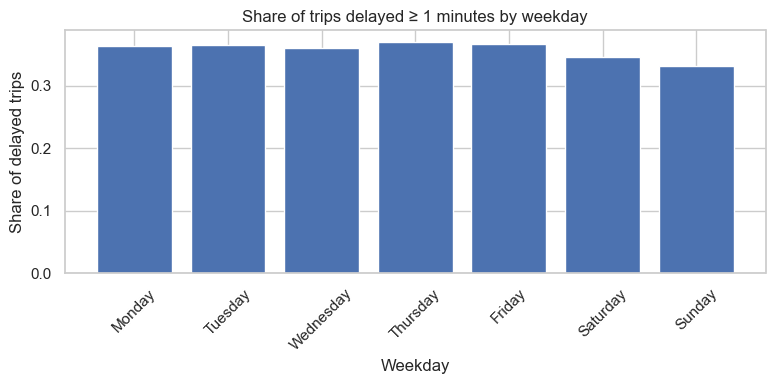

In [8]:
# EDA: delay patterns by day of week (DELAY_THRESHOLD = 1)

# Ensure weekday names are ordered from Monday to Sunday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["planned_weekday_name"] = df["planned_time"].dt.day_name()
df["planned_weekday_name"] = pd.Categorical(df["planned_weekday_name"],
                                            categories=weekday_order,
                                            ordered=True)

weekday_stats = (
    df.groupby("planned_weekday_name", observed=True)
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
      .sort_values("planned_weekday_name")
)

print(weekday_stats)

# Simple bar plot for delayed share by weekday
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weekday_stats["planned_weekday_name"], weekday_stats["delayed_rate"])
ax.set_title("Share of trips delayed ≥ 1 minutes by weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Share of delayed trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

      time_band  avg_delay  delayed_rate    n_obs
0         night   0.556155      0.298160    26516
1  morning_peak   0.866450      0.329361   366088
2        midday   1.008734      0.365920  3312074
3  evening_peak   1.176079      0.373013  2432120
4  late_evening   0.802138      0.327262  1219902


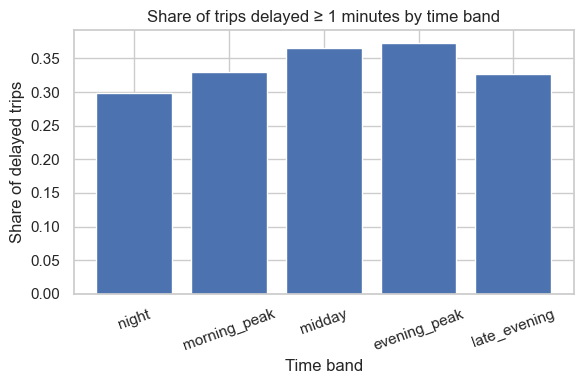

In [9]:
# EDA: delay patterns by coarse time bands (DELAY_THRESHOLD = 1)

time_band_order = ["night", "morning_peak", "midday", "evening_peak", "late_evening"]
df["time_band"] = pd.Categorical(df["time_band"],
                                 categories=time_band_order,
                                 ordered=True)

time_band_stats = (
    df.groupby("time_band", observed=True)
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
      .sort_values("time_band")
)

print(time_band_stats)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(time_band_stats["time_band"], time_band_stats["delayed_rate"])
ax.set_title("Share of trips delayed ≥ 1 minutes by time band")
ax.set_xlabel("Time band")
ax.set_ylabel("Share of delayed trips")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Network structure: operators, routes and stops

Next, we look at the structure of the network:

- average delay and delay rate by `operator`,
- by `route_short_name` (for routes with enough observations),
- and by `stop_id` (for the busiest stops).

The aim is to see whether some companies, lines or stops systematically experience more delays than others.

                                 operator  avg_delay  delayed_rate    n_obs
4   Ville de Luxembourg - Service Autobus   0.872064      0.394919  2701389
0  Régime Général des Transports Routiers   1.175180      0.349164  3608687
2                                    TICE   0.860380      0.305746  1040174

Number of operators with at least 50k observations: 3


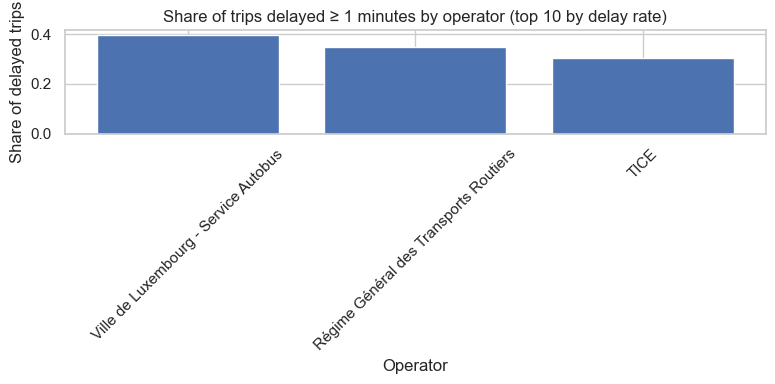

In [10]:
# EDA: delay patterns by operator (DELAY_THRESHOLD = 1)

operator_stats = (
    df.groupby("operator")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
)

# Focus on operators with enough observations (e.g. at least 50k stops)
min_obs = 50_000
operator_stats_big = operator_stats[operator_stats["n_obs"] >= min_obs].copy()

# Sort by delayed_rate descending to see worst performers
operator_stats_big = operator_stats_big.sort_values("delayed_rate", ascending=False)

print(operator_stats_big.head(15))
print("\nNumber of operators with at least 50k observations:", len(operator_stats_big))

# Bar plot: share of delayed trips for main operators

top_ops = operator_stats_big.head(10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top_ops["operator"], top_ops["delayed_rate"])
ax.set_title("Share of trips delayed ≥ 1 minutes by operator (top 10 by delay rate)")
ax.set_xlabel("Operator")
ax.set_ylabel("Share of delayed trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# EDA: delay patterns by route (DELAY_THRESHOLD = 1)

route_stats = (
    df.groupby("route_short_name")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
)

# Focus on routes with enough observations (e.g. at least 20k stops)
min_obs_route = 20_000
route_stats_big = route_stats[route_stats["n_obs"] >= min_obs_route].copy()

# Sort by delayed_rate descending to see worst routes among big ones
route_stats_big = route_stats_big.sort_values("delayed_rate", ascending=False)

print("Number of routes with at least", min_obs_route, "observations:", len(route_stats_big))
print(route_stats_big.head(15))

Number of routes with at least 20000 observations: 94
    route_short_name  avg_delay  delayed_rate   n_obs
67               191   2.028946      0.578054   29883
150              455   2.158756      0.570781   28673
248              811   1.835990      0.543800   75331
249              812   1.999084      0.543478   55649
147              424   1.502151      0.540815   20691
17               130   1.871675      0.515203   31506
245              802   1.952705      0.494658   26768
94                27   1.243874      0.492797   45950
256              824   1.443666      0.488546   34269
5                112   2.005064      0.484333   26265
65                19   1.381988      0.476951   20608
78                23   1.087960      0.475850  101864
91                26   1.020690      0.467170   92461
280              901   1.438838      0.453051   21108
69                20   1.380596      0.448462   25418


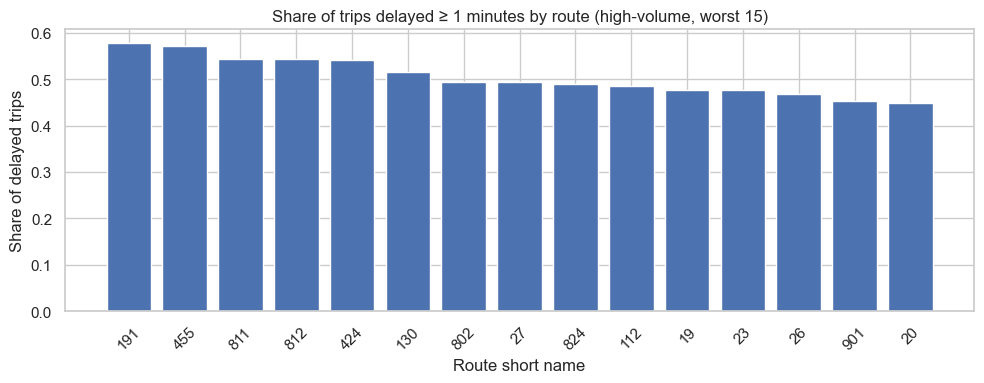

In [12]:
# Visual check: worst high-volume routes by delayed share (DELAY_THRESHOLD = 1)

top_routes = route_stats_big.head(15)  # already sorted by delayed_rate desc

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_routes["route_short_name"].astype(str), top_routes["delayed_rate"])
ax.set_title("Share of trips delayed ≥ 1 minutes by route (high-volume, worst 15)")
ax.set_xlabel("Route short name")
ax.set_ylabel("Share of delayed trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
best_routes = route_stats_big.sort_values("delayed_rate").head(15)
print(best_routes)

    route_short_name  avg_delay  delayed_rate   n_obs
51                17   0.367458      0.167898   61871
291              935   0.451178      0.182466   23862
62               182   0.701611      0.208845   21844
25               138   0.586619      0.214515   21150
125              341   0.452378      0.222504   26049
14               120   0.767170      0.226351   25160
260              832   0.870355      0.232218   21019
128              361   0.520880      0.238125   24042
15               121   0.816283      0.242816   28816
46               161   0.792921      0.247491   22518
56               174   1.002644      0.250983   29496
195              650   0.788936      0.261547   23988
13                12   0.602420      0.271167  104633
132                4   0.877495      0.282653  216619
202                7   0.649126      0.283742  152177


In [14]:
# EDA: delay patterns by stop (DELAY_THRESHOLD = 1)

stop_stats = (
    df.groupby("stop_id")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
)

# Focus on busy stops so results are more stable
min_obs_stop = 10_000  # you can adjust this if too many / too few
stop_stats_big = stop_stats[stop_stats["n_obs"] >= min_obs_stop].copy()

# Sort by delayed_rate descending to see worst busy stops
stop_stats_big = stop_stats_big.sort_values("delayed_rate", ascending=False)

print("Number of stops with at least", min_obs_stop, "observations:", len(stop_stats_big))
print(stop_stats_big.head(15))

Number of stops with at least 10000 observations: 183
        stop_id  avg_delay  delayed_rate  n_obs
458   140701029   2.472739      0.676672  10528
2249  221303004   1.865940      0.587191  11383
1156  190802001   1.914710      0.579869  11713
2083  220701011   2.049458      0.566917  10797
1181  190903013   2.038778      0.561818  14106
1671  200901003   1.665653      0.561674  14147
1180  190903012   2.000693      0.558942  14438
1672  200901004   1.643471      0.556959  14888
1178  190903007   2.028232      0.556640  14133
1685  200901020   1.673786      0.555612  19852
2252  221303009   1.801106      0.552660  10131
1679  200901014   1.621898      0.546534  14065
1248  200301003   2.024646      0.546341  10671
399   140401008   1.555191      0.536435  16742
2075  220701003   1.921173      0.535257  10707


## 7. Weather merge and impact on delays

We merge hourly weather data onto the bus dataset using the planned departure time. After the merge we:

- define simple rain-related flags (`is_rainy`, `is_heavy_rain`),
- compare average delay and delay rate between dry and rainy periods.

This quantifies whether rain has a meaningful effect on the risk of being delayed.

In [15]:
# Clean merge of hourly weather into bus dataset (DELAY_THRESHOLD = 1)

# 1) Drop any old weather columns if they exist
weather_prefixes = ["precipitation", "rain", "weathercode"]
cols_to_drop = [c for c in df.columns if any(c.startswith(p) for p in weather_prefixes)]
print("Dropping existing weather-related columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop, errors="ignore")

# 2) Load the new full-range weather file
WEATHER_PATH = "../data/sample/weather_lux_hourly_2025-08-17_2025-09-16.csv"
weather_df = pd.read_csv(WEATHER_PATH)

print("Weather raw shape:", weather_df.shape)
print(weather_df.head())

# 3) Prepare hourly keys
weather_df["time"] = pd.to_datetime(weather_df["time"])
weather_df["time_hour"] = weather_df["time"].dt.floor("h")

df["planned_time_hour"] = df["planned_time"].dt.floor("h")

# 4) Select weather columns to merge
weather_merge_cols = ["time_hour", "rain", "precipitation", "weathercode"]

df = df.merge(
    weather_df[weather_merge_cols],
    left_on="planned_time_hour",
    right_on="time_hour",
    how="left"
)

# Drop duplicate merge key from weather side
df = df.drop(columns=["time_hour"])

print("\nShape after weather merge:", df.shape)

# 5) Check missing rates in the weather columns
print("\nMissing rate in weather columns after merge:")
print(df[["rain", "precipitation", "weathercode"]].isna().mean())

Dropping existing weather-related columns: []
Weather raw shape: (1344, 5)
                  time  rain  precipitation  weathercode            time_hour
0  2025-07-24 00:00:00   0.0            0.0            3  2025-07-24 00:00:00
1  2025-07-24 01:00:00   0.0            0.0            3  2025-07-24 01:00:00
2  2025-07-24 02:00:00   0.5            0.5           53  2025-07-24 02:00:00
3  2025-07-24 03:00:00   0.4            0.4           51  2025-07-24 03:00:00
4  2025-07-24 04:00:00   0.4            0.4           51  2025-07-24 04:00:00

Shape after weather merge: (7356700, 20)

Missing rate in weather columns after merge:
rain             0.0
precipitation    0.0
weathercode      0.0
dtype: float64


In [16]:
# Weather features and basic EDA (DELAY_THRESHOLD = 1)

# Simple binary flags based on rain intensity (mm/h)
df["is_rainy"] = (df["rain"] > 0).astype(int)
df["is_heavy_rain"] = (df["rain"] >= 2.0).astype(int)

print("Value counts for is_rainy:")
print(df["is_rainy"].value_counts(normalize=True))

print("\nValue counts for is_heavy_rain:")
print(df["is_heavy_rain"].value_counts(normalize=True))

# Compare delay by rain vs dry
rain_stats = (
    df.groupby("is_rainy")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
)

heavy_rain_stats = (
    df.groupby("is_heavy_rain")
      .agg(
          avg_delay=("delay_minutes", "mean"),
          delayed_rate=("is_delayed", "mean"),
          n_obs=("is_delayed", "size")
      )
      .reset_index()
)

print("\nDelay stats by is_rainy (0=dry, 1=rain):")
print(rain_stats)

print("\nDelay stats by is_heavy_rain (0=no/normal rain, 1=heavy rain):")
print(heavy_rain_stats)

Value counts for is_rainy:
is_rainy
0    0.735262
1    0.264738
Name: proportion, dtype: float64

Value counts for is_heavy_rain:
is_heavy_rain
0    0.988318
1    0.011682
Name: proportion, dtype: float64

Delay stats by is_rainy (0=dry, 1=rain):
   is_rainy  avg_delay  delayed_rate    n_obs
0         0   0.986321      0.353365  5409104
1         1   1.117648      0.377639  1947596

Delay stats by is_heavy_rain (0=no/normal rain, 1=heavy rain):
   is_heavy_rain  avg_delay  delayed_rate    n_obs
0              0   1.018611      0.359437  7270760
1              1   1.230684      0.389784    85940


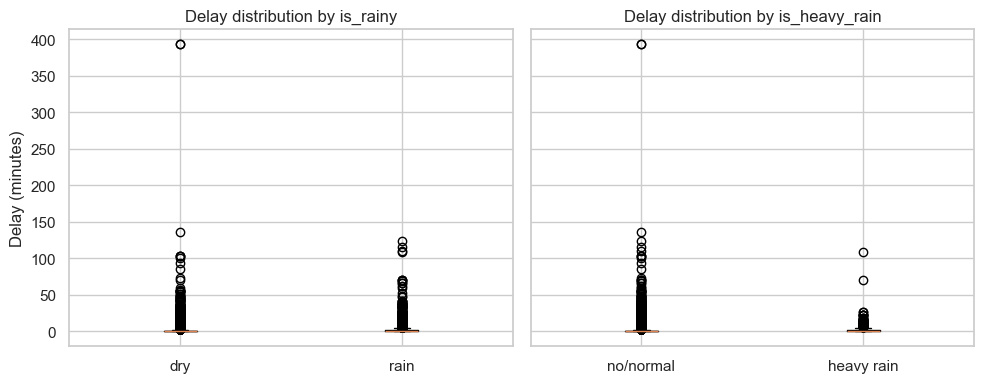

In [17]:
# Boxplots for delay vs rain flags (sample for readability)

# Sample a subset to keep plots light
sample = df.sample(n=200_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].boxplot(
    [
        sample.loc[sample["is_rainy"] == 0, "delay_minutes"],
        sample.loc[sample["is_rainy"] == 1, "delay_minutes"],
    ],
    tick_labels=["dry", "rain"],
)
axes[0].set_title("Delay distribution by is_rainy")
axes[0].set_ylabel("Delay (minutes)")

axes[1].boxplot(
    [
        sample.loc[sample["is_heavy_rain"] == 0, "delay_minutes"],
        sample.loc[sample["is_heavy_rain"] == 1, "delay_minutes"],
    ],
    tick_labels=["no/normal", "heavy rain"],
)
axes[1].set_title("Delay distribution by is_heavy_rain")

plt.tight_layout()
plt.show()

## 8. Correlations and modeling-ready dataset

To prepare for Part 3, we:

- compute a correlation matrix for numeric and binary features, 
- summarise which variables appear most related to `delay_minutes` and `is_delayed`,
- and then select a focused subset of columns for modeling (identifiers, time features, weather and the target).

The resulting table is exported as `df_model_delay.csv` and will be the input for the modeling notebooks.

                 delay_minutes  is_delayed  planned_hour  planned_weekday  \
delay_minutes         1.000000    0.494294      0.000298        -0.022979   
is_delayed            0.494294    1.000000     -0.008741        -0.014451   
planned_hour          0.000298   -0.008741      1.000000         0.004650   
planned_weekday      -0.022979   -0.014451      0.004650         1.000000   
is_weekend           -0.026023   -0.020534      0.035223         0.748138   
rain                  0.010333    0.009843      0.001532         0.000101   
precipitation         0.010333    0.009843      0.001532         0.000101   
is_rainy              0.021027    0.022315     -0.113002         0.027199   
is_heavy_rain         0.008269    0.006794      0.015936        -0.025518   

                 is_weekend      rain  precipitation  is_rainy  is_heavy_rain  
delay_minutes     -0.026023  0.010333       0.010333  0.021027       0.008269  
is_delayed        -0.020534  0.009843       0.009843  0.022315       

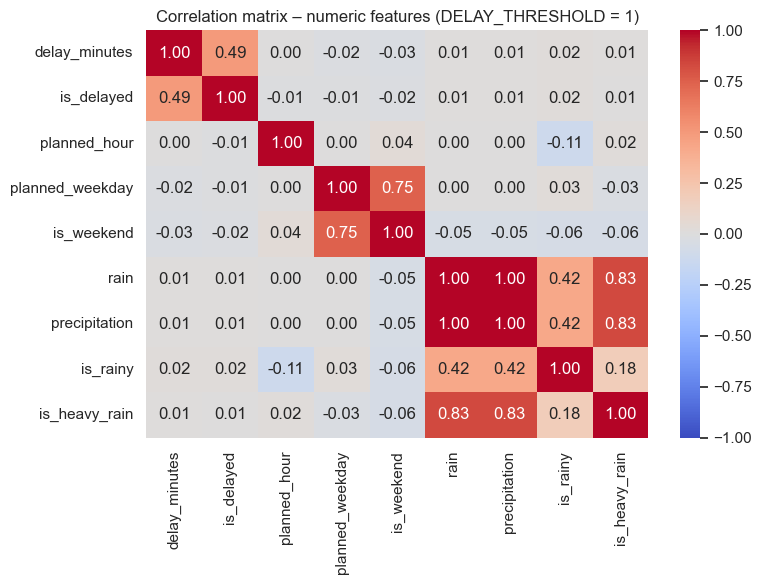

In [18]:
# Correlation matrix for numeric features (DELAY_THRESHOLD = 1)

numeric_cols = [
    "delay_minutes",
    "is_delayed",
    "planned_hour",
    "planned_weekday",
    "is_weekend",
    "rain",
    "precipitation",
    "is_rainy",
    "is_heavy_rain",
]

corr = df[numeric_cols].corr()
print(corr)

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
plt.title("Correlation matrix – numeric features (DELAY_THRESHOLD = 1)")
plt.tight_layout()
plt.show()


In [19]:
# Historical delay rates per route and per stop for delay >= 1 minutes

# Global delay rate in the whole dataset (fallback for unseen routes/stops)
global_delay_rate = df["is_delayed"].mean()
print(f"Global delay rate (>= 1 min): {global_delay_rate:.4f}")

# Average delay rate by route_short_name
route_delay_rate = (
    df.groupby("route_short_name")["is_delayed"]
    .mean()
)

# Average delay rate by stop_id
stop_delay_rate = (
    df.groupby("stop_id")["is_delayed"]
    .mean()
)

# Map these rates back to each row
df["route_delay_rate"] = df["route_short_name"].map(route_delay_rate)
df["stop_delay_rate"] = df["stop_id"].map(stop_delay_rate)

# If any route/stop has no historical rate (should be rare), fill with global rate
df["route_delay_rate"] = df["route_delay_rate"].fillna(global_delay_rate)
df["stop_delay_rate"] = df["stop_delay_rate"].fillna(global_delay_rate)

print("New columns created: 'route_delay_rate', 'stop_delay_rate'")
print(df[["route_delay_rate", "stop_delay_rate"]].describe())

Global delay rate (>= 1 min): 0.3598
New columns created: 'route_delay_rate', 'stop_delay_rate'
       route_delay_rate  stop_delay_rate
count      7.356700e+06     7.356700e+06
mean       3.597911e-01     3.597911e-01
std        9.740761e-02     1.354903e-01
min        0.000000e+00     0.000000e+00
25%        2.877938e-01     2.798165e-01
50%        3.771352e-01     3.896108e-01
75%        4.227578e-01     4.498058e-01
max        1.000000e+00     1.000000e+00


In [20]:
# Volume-based features: number of events per route and per stop (for modeling)

df["route_volume"] = (
    df.groupby("route_short_name")["route_short_name"]
      .transform("size")
)

df["stop_volume"] = (
    df.groupby("stop_id")["stop_id"]
      .transform("size")
)

print(df[["route_short_name", "route_volume"]].head())
print(df[["stop_id", "stop_volume"]].head())

  route_short_name  route_volume
0              413         44076
1              412         18202
2              412         18202
3              412         18202
4              501         13828
     stop_id  stop_volume
0  201103001         4567
1  201103001         4567
2  201103001         4567
3  201103001         4567
4  201103001         4567


In [21]:
# Modeling dataset for DELAY_THRESHOLD = 1

model_cols = [
    "stop_id",
    "operator",
    "route_id",
    "route_short_name",
    "route_volume",   # NEW
    "stop_volume",    # NEW
    "planned_hour",
    "planned_weekday",
    "is_weekend",
    "time_band",
    "rain",
    "is_rainy",
    "is_heavy_rain",
    "is_delayed",  # target
]

df_model = df[model_cols].copy()

print("Modeling dataset shape (delay >= 1):", df_model.shape)
print(df_model.head())

Modeling dataset shape (delay >= 1): (7356700, 14)
     stop_id                                operator  route_id  \
0  201103001  Régime Général des Transports Routiers      3209   
1  201103001  Régime Général des Transports Routiers      3208   
2  201103001  Régime Général des Transports Routiers      3208   
3  201103001  Régime Général des Transports Routiers      3208   
4  201103001  Régime Général des Transports Routiers      3210   

  route_short_name  route_volume  stop_volume  planned_hour  planned_weekday  \
0              413         44076         4567            20                4   
1              412         18202         4567            20                4   
2              412         18202         4567            20                4   
3              412         18202         4567            20                4   
4              501         13828         4567            20                4   

   is_weekend     time_band  rain  is_rainy  is_heavy_rain  is_delayed 

In [22]:
OUTPUT_PATH = "../data/df_model_delay.csv"  # adjust path if needed

df_model.to_csv(OUTPUT_PATH, index=False)
print("Saved modeling dataset (delay >= 1) to:", OUTPUT_PATH)

Saved modeling dataset (delay >= 1) to: ../data/df_model_delay.csv
